# Analyse des pathologies et traitements - Assurance Maladie (version Python pur)

# Objectif

Ce notebook présente une analyse statistique des effectifs de patients pris en charge par pathologie et par traitement en France.
L’étude a été réalisée en Python selon deux approches :
- Une version en Python natif (sans bibliothèque spécialisée),
- Une version en Python natif (sans bibliothèque spécialisée),

Cela permet de montrer deux approches différentes pour analyser le même jeu de données.

---

## Plan

1. Chargement et nettoyage
2. Indicateurs globaux
3. Analyse par pathologie
4. Analyse temporelle
5. Analyse territoriale
6. Détection d’anomalies
7. Analyse multi-pathologies

## Attention

<span style="color:red; font-weight:bold; font-size:16px;">
Cette analyse est réalisée sur un échantillon des données, présent dans le dossier data. Toutes les statistiques montrées ci-dessous, à la différence des scripts et notebooks PANDAS ne sont pas à prendre en compte, c'est fictif !
    
</span>

### 1. Chargement et nettoyage

In [5]:
"""
La première étape est de charger le fichier echantillon_effectifs.csv à 
l'aide d'un loader (qui est dans core/loader_csv.py pour le projet final).
On nettoie ensuite les lignes agrégées non exploitables.
"""

import csv
import sys
from pathlib import Path

projet_path = Path(r"C:\Users\Dell\Desktop\python\Analyse_pathologie")
sys.path.append(str(projet_path))

import utils.conversion as conversion

def charger_echantillon() -> list[dict]:
    csv_path = projet_path / "data" / "echantillon_effectifs.csv"
    
    echantillon = []
    conv = conversion.Conversion_donnees()
    
    with open(csv_path, encoding="utf-8-sig") as response:
        lecteur_csv = csv.DictReader(response, delimiter=";")
        
        for l in lecteur_csv:
            # Exclusion des lignes non exploitables
            if l["patho_niv1"] == "Total consommants tous régimes":
                continue
            if l["top"] == "POP_TOT_IND":
                continue
            if not l["Ntop"] or not l["prev"]:
                continue
            if l["dept"] == "999":
                continue 
            
            try:
                departement = conv.departement(l["dept"])
                pathologie, niveau_patho = conv.pathologie(l)
                ligne_convertie = {
                    "Annee": int(l["annee"]),
                    "Pathologie": pathologie,
                    "Niveau_pathologie": niveau_patho,
                    "Age": l["libelle_classe_age"],
                    "Sexe": l["libelle_sexe"],
                    "Code_departement": l["dept"].strip().upper(),
                    "Departement": departement,
                    "Ntop": int(l["Ntop"]),
                    "Npop": int(l["Npop"]),
                    "prev": float(l["prev"])
                }
                echantillon.append(ligne_convertie)
            except ValueError:
                continue
            
    return echantillon

In [11]:
# Affichage des 5 premières données pour montrer la structure

donnees = charger_echantillon()
print(donnees[:5])

[{'Annee': 2022, 'Pathologie': 'Maladies rares', 'Niveau_pathologie': 'patho_niv2', 'Age': 'de 10 à 14 ans', 'Sexe': 'hommes', 'Code_departement': '73', 'Departement': 'Savoie', 'Ntop': 20, 'Npop': 13540, 'prev': 0.17}, {'Annee': 2022, 'Pathologie': 'Maladies rares', 'Niveau_pathologie': 'patho_niv2', 'Age': 'de 10 à 14 ans', 'Sexe': 'hommes', 'Code_departement': '74', 'Departement': 'Haute-Savoie', 'Ntop': 50, 'Npop': 26550, 'prev': 0.169}, {'Annee': 2020, 'Pathologie': 'Insuffisance rénale chronique terminale', 'Niveau_pathologie': 'patho_niv1', 'Age': 'de 35 à 39 ans', 'Sexe': 'tous sexes', 'Code_departement': '67', 'Departement': 'Bas-Rhin', 'Ntop': 60, 'Npop': 71110, 'prev': 0.09}, {'Annee': 2020, 'Pathologie': 'Insuffisance rénale chronique terminale', 'Niveau_pathologie': 'patho_niv1', 'Age': 'de 35 à 39 ans', 'Sexe': 'tous sexes', 'Code_departement': '08', 'Departement': 'Ardennes', 'Ntop': 20, 'Npop': 14850, 'prev': 0.108}, {'Annee': 2022, 'Pathologie': 'Maladies rares', 'Nive

La fonction def charger_effectifs() remplit plusieurs rôles distincts.

### Importation du fichier csv

Le jeu de données initial est un fichier csv de 850Mo téléchargeable sur le site data.gouv. Pour tester les fonctions de `stats_python.py` nous avons décidé de traiter un échantillon qui reprend la base du fichier original.

### Nettoyage des données

Certaines données sont agrégées ou non exploitables et peuvent fausser les statistiques.
C’est le cas notamment pour :

- les pathologies intitulées `Total consommants tous régimes` ;

- les lignes dont le champ `top` vaut `POP_TOT_IND` ;

- le département `999`, qui représente la France entière.

Ces lignes sont filtrées afin de ne conserver que les données exploitables pour les analyses statistiques, et cela grâce à ce bloc :

```
for l in lecteur_csv:
    # Exclusion des lignes non exploitables
    if l["patho_niv1"] == "Total consommants tous régimes":
        continue
    if l["top"] == "POP_TOT_IND":
        continue
    if not l["Ntop"] or not l["prev"]:
        continue
    if l["dept"] == "999":
        continue 
```

### Création de la colonne pathologie

Pour chaque enregistrement, la fonction crée une colonne pathologie correspondant au niveau le plus précis disponible parmi les trois niveaux de pathologies (patho_niv3, patho_niv2, patho_niv1).

Le fonctionnement est le suivant :

- On prend d’abord patho_niv3 si elle est renseignée.

- Si patho_niv3 est vide, on utilise patho_niv2.

- Si patho_niv2 est également vide, on prend patho_niv1.

Cette approche garantit que chaque ligne possède un nom de pathologie exploitable, en privilégiant le niveau de détail le plus fin possible.

### 2. Indicateurs globaux

In [18]:
# Test rapide du jeu de données à l'aide des premières fonctions 

#import des fonctions stats_python
import core.stats_python as sp

print("Nombre de lignes :", sp.nombre_de_lignes(donnees))
print("Nombre de pathologies :", len(sp.pathologies_distinctes(donnees)))
print("Nombre de départements :", len(sp.departements_distincts(donnees)))
print("Nombre d'années :", len(sp.annees_distinctes(donnees)))
print("Nombre total de cas :", sp.nombre_de_cas(donnees))
print("Population totale :", sp.population_reference(donnees))
print("Prévalence globale (%) :", sp.prevalence_globale(donnees))
print("Prévalence moyenne (%) :", sp.prevalence_moyenne(donnees))

Nombre de lignes : 545
Nombre de pathologies : 16
Nombre de départements : 102
Nombre d'années : 7
Nombre total de cas : 485815
Population totale : 75742460
Prévalence globale (%) : 0.641
Prévalence moyenne (%) : 0.935


### Différence entre prévalence globale et prévalence moyenne

- **Prévalence globale** :  
  Elle est calculée sur l'ensemble des données en tenant compte de la population de chaque groupe.  
  Formule :   (total des cas / population totale) * 100
  Elle reflète la proportion réelle de cas dans la population étudiée.

- **Prévalence moyenne** :  
  C'est la moyenne arithmétique des prévalences calculées pour chaque sous-groupe (ex. par département, sexe ou tranche d'âge), **sans pondération par la taille des populations**.  
  Formule :  prevalence de chaque ligne étudiée / nombre de ligne(s) étudiée(s)
  Elle permet d’observer la tendance moyenne entre les sous-groupes, mais **ne reflète pas la prévalence réelle dans l’ensemble de la population**.

### 3. Analyse par pathologie

In [24]:
# Test de l'une des fonctions principales statistiques_descriptives

"""
Nous allons choisir une pathologie (obligatoire), mais pouvons aussi 
choisir en plus un sexe, une tranche d'âge, un département ou une année 
pour avoir les statistiques filtrées en utilisant la fonction filtrer_multi_criteres()
"""

patho = "Diabète"

# Nous devons d'abord filtrer la list[dict] pour la pathologie "Diabète"
donnees_patho = sp.filtrer_par_pathologie(donnees, patho)

# Statistiques
stats = sp.statistiques_descriptives(donnees_patho)

for k, v in stats.items():
    print(f"{k} : {v}")

Ntop totale : 81735
Npop totale : 3644570
Prevalence moyenne : 2.316
Prevalence mediane : 1.997
Prevalence min : 0.819
Prevalence max : 7.192
Ecart-type prevalence : 1.204


In [26]:
# Test de la même fonction avec un filtrage sur le sexe

donnees_filtrees = sp.filtrer_multi_criteres(donnees, patho, sexe="hommes")

stats_filtrees = sp.statistiques_descriptives(donnees_filtrees)

for k, v in stats_filtrees.items():
    print(f"{k} : {v}")

Ntop totale : 45610
Npop totale : 1373250
Prevalence moyenne : 3.121
Prevalence mediane : 2.917
Prevalence min : 1.346
Prevalence max : 7.192
Ecart-type prevalence : 1.158


In [27]:
"""
Maintenant on analyse la pathologie / traitement par sexe (ici pour le diabète).
Notre fonction stats_par_sexe retourne un dictionnaire montrant les stats pour 
les femmes et hommes.
"""

print(sp.stats_par_sexe(donnees, patho))

{'hommes': {'Ntop totale': 45610, 'Npop totale': 1373250, 'Prevalence moyenne': 3.121, 'Prevalence mediane': 2.917, 'Prevalence min': 1.346, 'Prevalence max': 7.192, 'Ecart-type prevalence': 1.158}, 'femmes': {'Ntop totale': 14310, 'Npop totale': 681950, 'Prevalence moyenne': 1.985, 'Prevalence mediane': 1.948, 'Prevalence min': 1.109, 'Prevalence max': 4.913, 'Ecart-type prevalence': 0.773}}


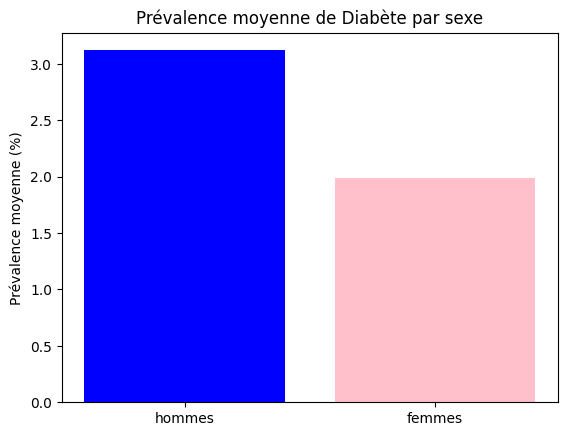

In [30]:
"""
Cela nous permet de faire un graphique comparatif à l'aide des données 
que l'on a pour les hommes et les femmes. 
On utilisera matplotlib pour l'affichage de graphique.
"""

import matplotlib.pyplot as plt

stats_p_sexe = sp.stats_par_sexe(donnees, patho)

categories = ['hommes', 'femmes']
prevalence_moyenne = [stats_p_sexe['hommes']['Prevalence moyenne'],
                       stats_p_sexe['femmes']['Prevalence moyenne']]

plt.bar(categories, prevalence_moyenne, color=['blue', 'pink'])
plt.title(f'Prévalence moyenne de {patho} par sexe')
plt.ylabel('Prévalence moyenne (%)')
plt.show()

In [31]:
# Test des fonctions ratio_cas_hf et difference_prevalence_sexe

print("Ratio des cas H/F : ", sp.ratio_cas_hf(donnees, patho))
print("Différence de prévalence hommes - femmes : ", sp.difference_prevalence_sexe(donnees, patho))

Ratio des cas H/F :  3.187
Différence de prévalence hommes - femmes :  1.223


In [32]:
"""
Ensuite, nous pouvons développer des statistiques par tranche d'âge.
Cette fonction filtre par tranche d'âge et applique la fonction statistiques_descriptives()
"""

print(sp.stats_par_tranche_age(donnees, patho))

{'de 20 à 24 ans': {'Ntop totale': 45, 'Npop totale': 18650, 'Prevalence moyenne': 0.836, 'Prevalence mediane': 0.836, 'Prevalence min': 0.836, 'Prevalence max': 0.836, 'Ecart-type prevalence': 0.0}, 'de 30 à 34 ans': {'Ntop totale': 300, 'Npop totale': 35370, 'Prevalence moyenne': 0.827, 'Prevalence mediane': 0.827, 'Prevalence min': 0.819, 'Prevalence max': 0.836, 'Ecart-type prevalence': 0.012}, 'de 35 à 39 ans': {'Ntop totale': 13870, 'Npop totale': 1059900, 'Prevalence moyenne': 1.208, 'Prevalence mediane': 1.185, 'Prevalence min': 0.888, 'Prevalence max': 1.586, 'Ecart-type prevalence': 0.186}, 'de 40 à 44 ans': {'Ntop totale': 35090, 'Npop totale': 1704160, 'Prevalence moyenne': 2.065, 'Prevalence mediane': 1.986, 'Prevalence min': 1.1, 'Prevalence max': 4.913, 'Ecart-type prevalence': 0.743}, 'de 45 à 49 ans': {'Ntop totale': 32430, 'Npop totale': 826490, 'Prevalence moyenne': 3.777, 'Prevalence mediane': 3.587, 'Prevalence min': 2.439, 'Prevalence max': 7.192, 'Ecart-type prev

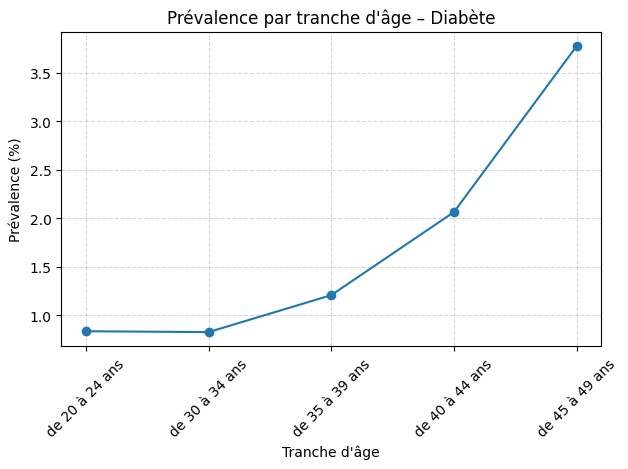

In [33]:
"""
Suite à ce dictionnaire, nous pouvons illustrer l'évolution d'une pathologie
en fonction de l'âge. Voici par exemple un graphique qui démontrer une 
évolution du diabète avec l'âge.
"""

stats_age = sp.stats_par_tranche_age(donnees, patho)

tranches = list(stats_age.keys())
prevalences = [stats_age[age]['Prevalence moyenne'] for age in tranches]

plt.figure()
plt.plot(tranches, prevalences, marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.title(f"Prévalence par tranche d'âge – {patho}")
plt.ylabel("Prévalence (%)")
plt.xlabel("Tranche d'âge")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
"""
Possibilité de calculer l'écart de prévalence entre deux tranches d'âge 
avec la fonction variation_prevalence_entre_ages.
"""

tranche_1 = "de 20 à 24 ans"
tranche_2 = "de 40 à 44 ans"

print(f"L'écart de prévalence entre la tranche '{tranche_1}' et '{tranche_2} est de {sp.variation_prevalence_entre_ages(donnees, patho, tranche_1, tranche_2)}.")

L'écart de prévalence entre la tranche 'de 20 à 24 ans' et 'de 40 à 44 ans est de 1.818.


In [35]:
# Nous pouvons voir aussi l'âge central pour une pathologie

age_central = sp.age_central_pathologie(donnees, patho)
print(f"L'âge central de la pathologie '{patho}' est {age_central[0]}, avec une prévalence de {age_central[1]} %.")

L'âge central de la pathologie 'Diabète' est de 45 à 49 ans, avec une prévalence de 3.924 %.


### 4. Analyse temporelle

In [36]:
# Développons maintenant les statistiques par année (il y a 9 années étudiées).

stats_annee = sp.stats_par_annee(donnees, patho)
print(stats_annee)

{2019: {'Ntop totale': 80635, 'Npop totale': 3613230, 'Prevalence moyenne': 2.332, 'Prevalence mediane': 2.009, 'Prevalence min': 0.819, 'Prevalence max': 7.192, 'Ecart-type prevalence': 1.204}, 2021: {'Ntop totale': 300, 'Npop totale': 15670, 'Prevalence moyenne': 1.149, 'Prevalence mediane': 1.149, 'Prevalence min': 1.149, 'Prevalence max': 1.149, 'Ecart-type prevalence': 0.0}, 2022: {'Ntop totale': 800, 'Npop totale': 15670, 'Prevalence moyenne': 1.149, 'Prevalence mediane': 1.149, 'Prevalence min': 1.149, 'Prevalence max': 1.149, 'Ecart-type prevalence': 0.0}}


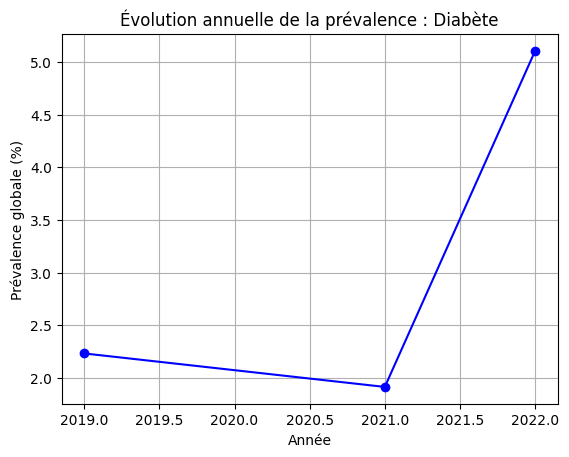

In [42]:
"""
Nous pouvons par exemple ici voir, pour la pathologie étudiée (Diabète) 
l'évolution annuelle de la prévalence grâce au graphique suivant.
"""

annees = sorted(stats_annee.keys())
prevalences_globales = [
    round((stats_annee[annee]["Ntop totale"] / stats_annee[annee]["Npop totale"]) * 100, 3)
    for annee in annees]

plt.figure()
plt.plot(annees, prevalences_globales, marker='o', linestyle='-', color='blue')
plt.title(f"Évolution annuelle de la prévalence : {patho}")
plt.xlabel("Année")
plt.ylabel("Prévalence globale (%)")
plt.grid(True)
plt.show()

In [43]:
# Calculons la variation annuelle de la prévalence pour une pathologie données
print(sp.variation_annuelle(donnees, patho))

{2021: {'difference absolue': -0.318, 'valeur relative': -14.247}, 2022: {'difference absolue': 3.191, 'valeur relative': 166.719}}


Cette fonction `def variation_annuelle(donnees, pathologie)`renvoie un dictionnaire avec les années à partir de la deuxième année étudiée (ici, 2021 car aucune donnée en 2020) jusqu'à la dernière.
Nous retrouvons par année deux valeurs :

- La différence absolue de la prévalence par rapport à l'année précédente. Méthode de calcul : **prev année n - prev année n-1**
- La valeur relative. Méthode de calcul : **(différence absolue calculée précédemment / prev année n-1) * 100**


In [44]:
"""
La tendance générale permet de déterminer une tendance de la prévalence 
globale d'une pathologie sur la période étudiée.

La tendance est calculée à partir de la moyenne des variations
annuelles absolues de prévalence :

- moyenne > 0  → "hausse"
- moyenne < 0  → "baisse"
- moyenne = 0  → "stable"

Si aucune variation ne peut être calculée (ex. une seule année
disponible ou données absentes), la fonction retourne None.
"""

tendance = sp.tendance_generale(donnees, patho)
print(f"Pendant la période étudiée, la prévalence de la pathologie {patho} est en {tendance}.")

Pendant la période étudiée, la prévalence de la pathologie Diabète est en hausse.


### 5. Analyse territoriale

L'analyse territoriale est intéressante car elle permet de distinguer les écarts de prévalence d'une pathologie en fonction du territoire.

Celle-ci est étudiée par département. On couvre d'ailleurs les 101 départements français, triés et traduits (code département -> nom département) via la fonction `def cle_tri` interne à la fonction `def stats_par_departement`.

In [53]:
# Chargement des statistiques par département et affichage des 5 premières valeurs

stats_dept = sp.stats_par_departement(donnees, patho)
for i, (k, v) in enumerate(stats_dept.items()):
    if i >= 5:
        break
    print(k, v)

01 {'Departement': 'Ain', 'Ntop totale': 760, 'Npop totale': 20560, 'Prevalence moyenne': 3.672, 'Prevalence mediane': 3.672, 'Prevalence min': 3.672, 'Prevalence max': 3.672, 'Ecart-type prevalence': 0.0}
02 {'Departement': 'Aisne', 'Ntop totale': 1730, 'Npop totale': 60840, 'Prevalence moyenne': 3.221, 'Prevalence mediane': 2.907, 'Prevalence min': 1.586, 'Prevalence max': 5.171, 'Ecart-type prevalence': 1.813}
2A {'Departement': 'Corse-du-Sud', 'Ntop totale': 100, 'Npop totale': 8730, 'Prevalence moyenne': 1.18, 'Prevalence mediane': 1.18, 'Prevalence min': 1.18, 'Prevalence max': 1.18, 'Ecart-type prevalence': 0.0}
03 {'Departement': 'Allier', 'Ntop totale': 440, 'Npop totale': 10100, 'Prevalence moyenne': 4.377, 'Prevalence mediane': 4.377, 'Prevalence min': 4.377, 'Prevalence max': 4.377, 'Ecart-type prevalence': 0.0}
04 {'Departement': 'Alpes-de-Haute-Provence', 'Ntop totale': 260, 'Npop totale': 13410, 'Prevalence moyenne': 2.106, 'Prevalence mediane': 2.106, 'Prevalence min': 

Nous pouvons ainsi voir les 5 départements les + touchés par le diabète avec la fonction `def top_departements` (nous l'afficherons ci-dessous). 

Nous pouvons aussi afficher les 10 départements les moins touchés avec `def bottom_departements`.

In [54]:
# Affichage des 10 départements les plus touchés par le diabète

print(sp.top_departements(donnees, patho))

[(1, 'Guyane', 5.783), (2, 'Seine-Saint-Denis', 4.941), (3, 'La Réunion', 4.915), (4, 'Essonne', 4.756), (5, 'Somme', 4.495), (6, 'Allier', 4.356), (7, 'Haut-Rhin', 4.252), (8, 'Eure-et-Loir', 4.08), (9, 'Rhône', 3.787), (10, 'Ain', 3.696)]


In [55]:
"""
Nous avons aussi la possibilité de calculer la moyenne nationale de la 
prévalence pour une pathologie donnée. Cela nous permettra ensuite d'utiliser 
la fonction ecart_a_la_moyenne pour voir les département + ou - écartés de la 
moyenne.
"""

moy_nat = sp.moyenne_nationale(donnees, patho)
print(f"La moyenne nationale de la pathologie '{patho}' est : {moy_nat} %.")

La moyenne nationale de la pathologie 'Diabète' est : 2.243 %.


In [57]:
# Affichage de l'écart à la moyenne des 10 premiers départements étudiés

print(sp.ecart_a_la_moyenne(donnees, patho)[:10])

[('Haute-Vienne', -1.693), ('Hautes-Alpes', -1.27), ('Aveyron', -1.204), ('Manche', -1.178), ('Corse-du-Sud', -1.098), ('Hauts-de-Seine', -1.09), ('Finistère', -1.061), ('Loire', -1.038), ('Doubs', -1.014), ('Lot-et-Garonne', -0.958)]


In [ ]:
# Affichage graphique des 10 écarts à la moyenne les plus faibles et plus fortes
df_ecart = sp.ecart_a_la_moyenne(df, patho)
df_ecart = df_ecart.sort_values("ecart_a_la_moyenne")

df_selection = pd.concat([
    df_ecart.head(10),
    df_ecart.tail(10)])

plt.figure()
plt.barh(df_selection["departement_nom"], df_selection["ecart_a_la_moyenne"])
plt.title("Écart à la moyenne nationale")
plt.xlabel("Écart de prévalence (%)")
plt.show()

### 6. Détection d'anomalies

In [59]:
"""
Affichage du z-score par rapport à la moyenne nationale pour les 10 premiers 
départements étudiés
"""

z_score = sp.z_score_prevalence(donnees, patho)
print(z_score[:10])

[('Haute-Vienne', -1.653), ('Hautes-Alpes', -1.24), ('Aveyron', -1.176), ('Manche', -1.15), ('Corse-du-Sud', -1.072), ('Hauts-de-Seine', -1.064), ('Finistère', -1.036), ('Loire', -1.013), ('Doubs', -0.99), ('Lot-et-Garonne', -0.935)]


Le **z-score de prévalence** permet de mesurer l’écart d’un territoire (département) par rapport à la moyenne nationale, en tenant compte de la dispersion des données.

Le but est d'identifier si une prévalence locale est :
- proche de la moyenne nationale,
- significativement plus élevée,
- ou significativement plus faible.

La formule est : [Z = frac{X - mu}{sigma}]

avec :

- X : prévalence du territoire étudié  
- mu : moyenne nationale des prévalences  
- sigma : écart-type des prévalences  

Ainsi, un département avec un z-score élevé présente une prévalence significativement différente de la situation nationale.

In [60]:
"""
Grâce à cela, nous pouvons déterminer les départements avec des valeurs 
significativement éloignée de la moyenne nationale avec un z-score dépassant 
le seuil de -2 ou 2
"""

print(sp.valeurs_aberrantes(donnees, patho))

[('Allier', 2.063), ('Somme', 2.199), ('Essonne', 2.454), ('La Réunion', 2.609), ('Seine-Saint-Denis', 2.634), ('Guyane', 3.456)]


**Attention, la valeur des z-scores et des stats sont un cumul sur les 9 années !**

Pour pouvoir étudier les pathologies par département et par année distinctes, nous avons donc créée des fonctions pouvant séparer les statistiques par année et par département.

In [61]:
# Affichage des données par département et par année

stats_dept_annee = sp.stats_par_departement_annee(donnees, patho)
print(stats_dept_annee)

[(2019, {'01': {'Departement': 'Ain', 'Ntop totale': 760, 'Npop totale': 20560, 'Prevalence moyenne': 3.672, 'Prevalence mediane': 3.672, 'Prevalence min': 3.672, 'Prevalence max': 3.672, 'Ecart-type prevalence': 0.0}, '02': {'Departement': 'Aisne', 'Ntop totale': 1730, 'Npop totale': 60840, 'Prevalence moyenne': 3.221, 'Prevalence mediane': 2.907, 'Prevalence min': 1.586, 'Prevalence max': 5.171, 'Ecart-type prevalence': 1.813}, '2A': {'Departement': 'Corse-du-Sud', 'Ntop totale': 100, 'Npop totale': 8730, 'Prevalence moyenne': 1.18, 'Prevalence mediane': 1.18, 'Prevalence min': 1.18, 'Prevalence max': 1.18, 'Ecart-type prevalence': 0.0}, '03': {'Departement': 'Allier', 'Ntop totale': 440, 'Npop totale': 10100, 'Prevalence moyenne': 4.377, 'Prevalence mediane': 4.377, 'Prevalence min': 4.377, 'Prevalence max': 4.377, 'Ecart-type prevalence': 0.0}, '04': {'Departement': 'Alpes-de-Haute-Provence', 'Ntop totale': 260, 'Npop totale': 13410, 'Prevalence moyenne': 2.106, 'Prevalence mediane

In [62]:
# Moyenne nationale par dept et par année pour une pathologie

moy_nat_annee = sp.moyenne_nationale_annee(donnees, patho)
print(moy_nat_annee)

{2019: 2.232, 2021: 1.914, 2022: 5.105}


In [65]:
# Détermination du z-score par année et par département

print(sp.z_score_prevalence_annee(donnees, patho))

{2019: [('Haute-Vienne', -1.633), ('Hautes-Alpes', -1.222), ('Aveyron', -1.158), ('Manche', -1.133), ('Corse-du-Sud', -1.055), ('Tarn-et-Garonne', -1.051), ('Hauts-de-Seine', -1.047), ('Finistère', -1.019), ('Loire', -0.997), ('Doubs', -0.974), ('Lot-et-Garonne', -0.919), ('Haute-Loire', -0.902), ('Mayenne', -0.828), ('Jura', -0.822), ('Maine-et-Loire', -0.801), ('Loiret', -0.793), ('Paris', -0.786), ('Loire-Atlantique', -0.759), ("Côte-d'Or", -0.755), ('Morbihan', -0.745), ('Gard', -0.724), ('Hautes-Pyrénées', -0.696), ('Var', -0.675), ('Vendée', -0.654), ('Lozère', -0.637), ('Haute-Marne', -0.622), ('Eure', -0.567), ('Pyrénées-Atlantiques', -0.524), ('Vaucluse', -0.517), ('Tarn', -0.489), ('Ille-et-Vilaine', -0.429), ('Dordogne', -0.407), ('Drôme', -0.354), ('Moselle', -0.343), ('Creuse', -0.342), ('Seine-et-Marne', -0.334), ('Ardèche', -0.325), ("Côtes-d'Armor", -0.305), ('Alpes-de-Haute-Provence', -0.284), ('Corrèze', -0.278), ('Vosges', -0.255), ('Haute-Saône', -0.228), ('Meuse', 

In [67]:
"""
Déterminantion des années anormales (seuil de 2), affiche une liste vide 
si aucune valeur
"""

print(sp.annees_anormales(donnees, patho))

[]


### 7. Analyse multi-pathologies

In [68]:
"""
Nous pouvons désormais classer les pathologies selon leur niveau de prévalence
à l’aide d’un filtre paramétrable.
Par défaut, aucun filtre n’est appliqué : le classement est donc effectué
sur l’ensemble des données (toutes années confondues, tous sexes,
tous départements et toutes tranches d’âge).
Il est toutefois possible d’appliquer des filtres spécifiques
(année, sexe, département, tranche d’âge) afin d’affiner l’analyse.
"""

print(sp.top_pathologies(donnees, top_n=10)) #top_n pour montrer le nombre de résultats

[('Transplantation rénale', 3.241), ('Diabète', 2.243), ('VIH', 1.634), ("Séquelle d'accident vasculaire cérébral", 1.231), ('Maladies cardiovasculaires', 0.632), ('Cancer colorectal', 0.61), ('Traitements neuroleptiques (hors pathologies)', 0.562), ('Hypertension essentielle', 0.325), ('Diabète de type 2', 0.308), ('Maladies rares', 0.145)]


In [72]:
"""
Retourne les pathologies avec la croissance la plus forte entre une année 
et une autre. Retourne la prévalence globale annuelle des deux années et 
la croissance absolue.
"""

print(sp.pathologies_croissance_forte(donnees, 2019, 2022))
# Ici, il n'y aura qu'une pathologie affichée car c'est la seule à être étudiée sur les 2 années

[('Diabète', 2.874)]


In [74]:
# Affichage d'un résumé global de notre dataset

print(sp.resume_global_avance(donnees))

{'nb_lignes': 545, 'nb_pathologies': 16, 'nb_departements': 102, 'nb_annees': 7, 'total_cas': 485815, 'population_totale': 75742460, 'prevalence_globale': 0.641, 'pathologie_plus_prevalente': 'Transplantation rénale', 'prevalence_pathologie_top': 3.241, 'departement_plus_impacte': 'Meuse', 'prevalence_departement_top': 2.052, 'annee_plus_critique': 2019, 'prevalence_annee_critique': 2.188, 'tendance_moyenne_annuelle': 0.185}


## Conclusion

Ce notebook a permis d’analyser les effectifs de patients pris en charge
par pathologie et par traitement en France à partir des données de l’Assurance Maladie.

Après une phase de **chargement et de nettoyage**, les données ont été structurées sous forme de **listes et dictionnaires Python**, garantissant la cohérence et la fiabilité des indicateurs calculés.
Les **indicateurs globaux** ont fourni une première vision du volume et de la diversité des pathologies étudiées.

L’analyse détaillée a porté successivement sur :

- La **comparaison des pathologies** selon leur niveau de prévalence,
- L’**évolution temporelle**, afin d’identifier les tendances et variations d’une année à l’autre,
- Les **disparités territoriales**, mettant en évidence des écarts entre départements,
- La **détection d’anomalies statistiques**, notamment grâce au calcul des écarts à la moyenne nationale et des z-scores,
- Une **analyse multi-pathologies**, permettant d’observer des dynamiques plus globales.

Cette étude montre une **approche structurée avec Python pur** : manipuler des structures de données natives, définir des indicateurs pertinents, comparer les observations et interpréter les résultats.

L’utilisation exclusive de Python natif montre qu’une analyse robuste est possible, mais pour de gros volumes de données, l’usage de bibliothèques spécialisées comme Pandas reste préférable pour plus d’efficacité et de rapidité.